# Explore K-Radar Data

First we have to define the path to the dataset and the configuration file used to load the data.

In [1]:
from dprt.utils.config import load_config

# Define data path
src = '/root/autodl-tmp/autodl-tmp/data/kradar'
cfg = '/root/autodl-tmp/autodl-tmp/DPFT-main/config/kradar.json'

# Load dataset configuration
config = load_config(cfg)

#### Load the data
In a seceond step we have to load the data for the raw dataset files to make it accesable to our subsequent tasks.

In [2]:
# from dprt.datasets import prepare

# # Create preperator instance
# preperator = prepare(config['dataset'], config)

# # Get single dataset sample
# dataset_paths = preperator.get_dataset_paths(src)
# sequence_paths = preperator.get_sequence_paths(next(iter(dataset_paths['train'].values())))
# sample = next(iter(sequence_paths.values()))

#### Visualize the data
Now we are ready to explore the data and visualize it to get a first impression of what we a working with. Therefore, we are first importing the visualization package.

*When you are working within a docker, please don't forget to enable xhost access:* `sudo xhost +local:docker`

In [1]:
from dprt.utils import visu

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/root/miniconda3/lib/python3.10/site-packages/torch/cuda/__init__.py:51: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


To get an image of the current scene, we will first visualize the data of one of the front cameras.

In [1]:
import cv2
filename='/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00504_00467/mono.jpg'
image = cv2.imread(filename)


In [2]:
# Load front camera data
# camera_front, _ = preperator.get_camera_data(sample['camera_front'])

# Visualize camera data
visu.visu_camera_data(image)

NameError: name 'visu' is not defined

To get an better understanding of the three dimensional objects and structures, we can also have a look at the associated lidar data as well as the annotated objects.

In [ ]:
import numpy as np
point_cloud = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/20/00038_00005/os1.npy')

In [1]:
import numpy as np

os1 = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00504_00467/os1.npy')

print(type(os1))
print(os1.shape)
print(os1.dtype)


<class 'numpy.ndarray'>
(200676, 9)
float32


In [ ]:
np.set_printoptions(precision=3, suppress=True)
print(os1[:5])


In [2]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_file = "/root/autodl-tmp/autodl-tmp/DPFT-main/result/20260130-144417-744/events.out.tfevents.1769755460.autodl-container-733445845f-4401119a.13389.0"

ea = EventAccumulator(event_file)
ea.Reload()

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['train/loss_total_class', 'train/loss_object_class', 'train/loss_center', 'train/loss_size', 'train/loss_angle', 'train/loss', 'train/mAP', 'train/mGIoU', 'train/learning_rate', 'val/loss_total_class', 'val/loss_object_class', 'val/loss_center', 'val/loss_size', 'val/loss_angle', 'val/loss', 'val/mAP', 'val/mGIoU'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [32]:
import numpy as np
point_cloud = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/26/00006_00001/description.npy')
print(point_cloud.shape)
print(point_cloud)


(3,)
[8. 0. 3.]


In [5]:
boxes = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/20/00038_00005/labels.npy')

In [6]:
import numpy as np

# 已有数据
boxes_lidar = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/20/00038_00005/labels.npy')          # (M, 9)
radar_to_lidar = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/20/00038_00005/ra_info.npy')  # (4, 4)

# 计算逆变换
lidar_to_radar = np.linalg.inv(radar_to_lidar)

# 拷贝一份，避免原地修改
boxes_radar = boxes_lidar.copy()

# 使用与你原来完全一致的逻辑做“反变换”
boxes_radar[:, :3] = np.einsum(
    'ij,...j->...i',
    lidar_to_radar,
    np.column_stack((boxes_lidar[:, :3], np.ones(boxes_lidar.shape[0])))
)[:, :3]


In [7]:
import matplotlib.pyplot as plt

def save_bev(pc, boxes, save_path="bev.png"):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.scatter(pc[:,0], pc[:,1], s=1, c='gray')
    for box in boxes:
        x, y, _, yaw, l, w, _, _, _ = box
        corners = np.array([[-l/2,-w/2],[l/2,-w/2],[l/2,w/2],[-l/2,w/2],[-l/2,-w/2]])
        R = np.array([[np.cos(yaw),-np.sin(yaw)],[np.sin(yaw),np.cos(yaw)]])
        corners = corners @ R.T + np.array([x,y])
        ax.plot(corners[:,0], corners[:,1], 'r-')
    ax.set_aspect('equal')
    plt.savefig(save_path, dpi=300)
    plt.close()


In [11]:
save_bev(point_cloud, boxes_t, "bev_boxes.png")


In [9]:
# # Load lidar data
# point_cloud = preperator.get_lidar_data(sample['os2'])

# # Load bounding boxes
# boxes = preperator.get_boxes(sample['label'])
# point_cloud = np.load('os1.npy')
# boxes = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/1/00033_00001/labels.npy')
# Visualize lidar data
visu.visu_lidar_data(point_cloud, boxes, xlim=[-100, 100], ylim=[-100, 100])

: 

RA shape: (256, 107, 6)


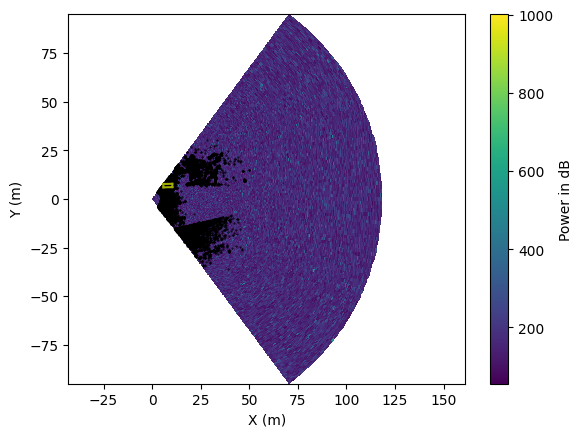

In [10]:
import numpy as np
from dprt.utils import visu
from dprt.datasets.kradar.utils import radar_info

# 加载处理后的数据
ra = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/44/00161_00152/ra.npy')
labels = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/44/00161_00152/labels.npy')
os1 = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/44/00161_00152/os1.npy')

print(f"RA shape: {ra.shape}")  # 先检查实际形状

# 提取 RA 数据的第一个通道 (rcs_max) - 已经是 dB 单位
ra_grid_db = ra[:, :, 2]

# 将 dB 转回线性功率值
ra_grid = 10 ** (ra_grid_db / 10)

# 设置正确的 raster - azimuth 保持度数，不转换为弧度！
# 根据实际 RA 形状选择 range_raster
if ra.shape[0] == 256:
    range_raster = np.array(radar_info.range_raster)  # 完整的 256 bins
elif ra.shape[0] == 248:
  range_raster = np.array(radar_info.range_raster[4:252])  # 裁剪后的 248 bins
else:
  raise ValueError(f"Unexpected RA range dimension: {ra.shape[0]}")

azimuth_raster = np.array(radar_info.azimuth_raster)  # 保持度数！

raster = [range_raster, azimuth_raster]

# 可视化 RA 数据
visu.visu_2d_radar_data(
    grid=ra_grid,
    dims='ra',
    boxes=labels,
    points=os1,
    raster=raster,
    cart=True,
    roi=True,
    label=('X (m)', 'Y (m)'),
    cm='viridis'
)

In [11]:
print(labels)

[[ 8.106965   6.8699136 -0.628     -3.1154127  4.6        1.7072968
   1.5558014  0.         0.       ]]


RA shape: (256, 107, 6)


/root/autodl-tmp/autodl-tmp/DPFT-main/src/dprt/utils/visu.py:394: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p = ax.pcolormesh(x_mesh, y_mesh, rcs.T, cmap=cm, shading='nearest')


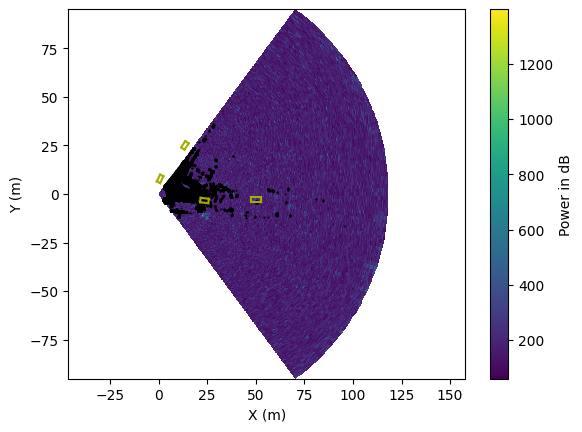

In [20]:
import numpy as np
from dprt.utils import visu
from dprt.datasets.kradar.utils import radar_info

# 加载处理后的数据
ra = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00504_00467/ra.npy')
labels = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00504_00467/labels.npy')
os1 = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00504_00467/os1.npy')

print(f"RA shape: {ra.shape}")  # 先检查实际形状

# 提取 RA 数据的第一个通道 (rcs_max) - 已经是 dB 单位
ra_grid_db = ra[:, :, 2]

# 将 dB 转回线性功率值
ra_grid = 10 ** (ra_grid_db / 10)

# 设置正确的 raster - azimuth 保持度数，不转换为弧度！
# 根据实际 RA 形状选择 range_raster
if ra.shape[0] == 256:
    range_raster = np.array(radar_info.range_raster)  # 完整的 256 bins
elif ra.shape[0] == 248:
  range_raster = np.array(radar_info.range_raster[4:252])  # 裁剪后的 248 bins
else:
  raise ValueError(f"Unexpected RA range dimension: {ra.shape[0]}")

azimuth_raster = np.array(radar_info.azimuth_raster)  # 保持度数！

raster = [range_raster, azimuth_raster]


# 可视化 RA 数据
visu.visu_2d_radar_data(
    grid=ra_grid,
    dims='ra',
    boxes=labels,
    points=os1,
    raster=raster,
    cart=True,
    roi=True,
    label=('X (m)', 'Y (m)'),
    cm='viridis'
)

In [5]:
import numpy as np

# 加载处理后的数据
ra = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/train/20/00479_00446/ra.npy')
ra.shape

(256, 107, 6)

In [10]:
labels.shape

(14, 9)

Labels shape: (5, 9)
OS1 shape: (170436, 9)


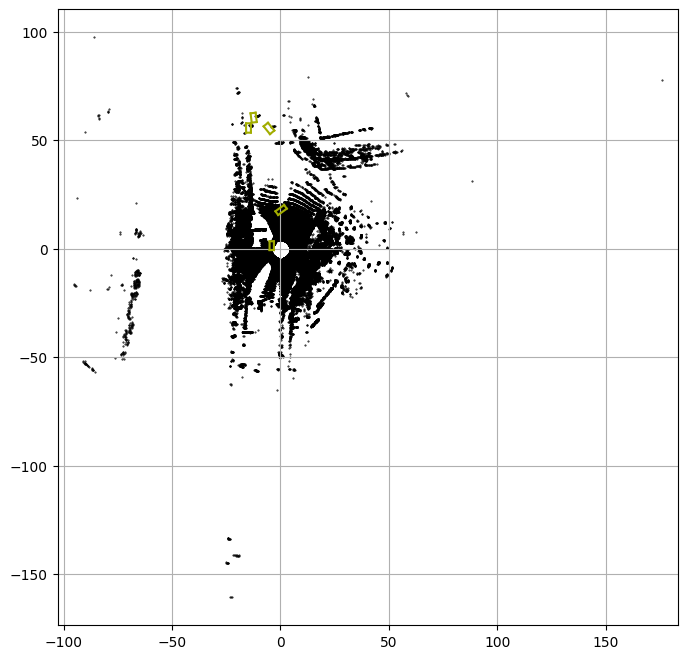

In [42]:
  import numpy as np
  import matplotlib.pyplot as plt
  from dprt.utils import visu

  # 加载处理后的数据
  labels = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/5/00509_00478/labels.npy')
  os1 = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/5/00509_00478/os1.npy')

  print(f"Labels shape: {labels.shape}")
  print(f"OS1 shape: {os1.shape}")

  # 创建图形和坐标轴
  fig = plt.figure(figsize=(8, 8))
  ax = fig.add_subplot(1, 1, 1)
  # labels[:,3]=0
  # 方式1: 在 X-Y 平面上可视化边界框（俯视图 - 最常用）
  visu.visu_2d_boxes(ax=ax, boxes=labels, dims=(1, 0), cart=True, flip=True)
  visu.visu_2d_lidar_points(ax=ax, points=os1, dims=(1, 0), cart=True, flip=False)
  # ax.set_xlim(-100, 100)   # Y轴范围
  # ax.set_ylim(-100, 100)    # X轴范围

  ax.axis('equal')
  ax.axis('equal')
  ax.grid(True)

Labels shape: (7, 9)
OS1 shape: (215804, 9)


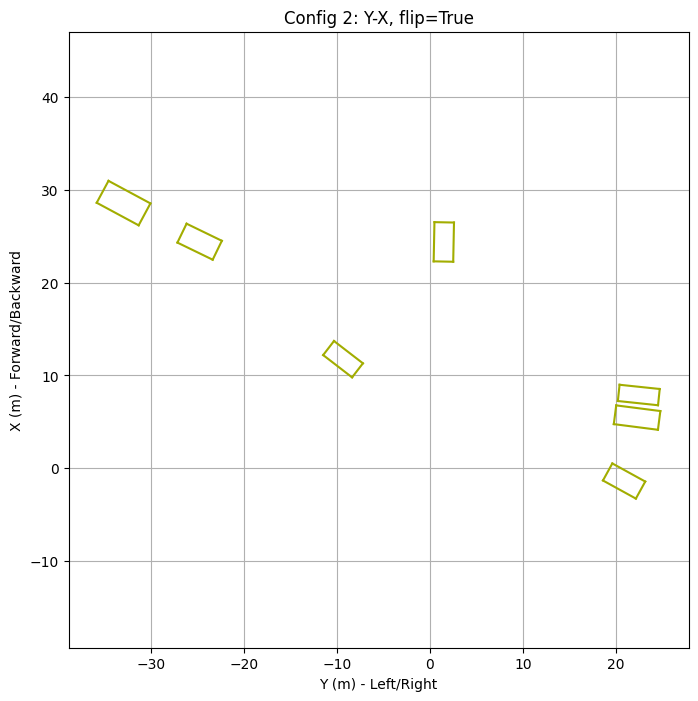

In [47]:
  import numpy as np
  import matplotlib.pyplot as plt
  from dprt.utils import visu

  # 加载处理后的数据
  labels = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00488_00451/labels.npy')
  os1 = np.load('/root/autodl-tmp/autodl-tmp/data/kradar/test/19/00488_00451/os1.npy')

  print(f"Labels shape: {labels.shape}")
  print(f"OS1 shape: {os1.shape}")

  # 创建多个子图来对比不同配置
  fig, ax = plt.subplots(1, 1, figsize=(8, 8))

  # # 配置1: 标准 BEV (X向前, Y向左) - 前方在上
  # ax = axes[0, 0]
  # visu.visu_2d_boxes(ax=ax, boxes=labels, dims=(1, 0), cart=True, flip=False)
  # visu.visu_2d_lidar_points(ax=ax, points=os1, dims=(1, 0), cart=True, flip=True)
  # ax.set_xlabel('Y (m) - Left/Right')
  # ax.set_ylabel('X (m) - Forward/Backward')
  # ax.set_title('Config 1: Y-X, no flip')
  # ax.axis('equal')
  # ax.grid(True)

  # 配置2: BEV 翻转 Y 轴
  # ax = axes[0, 1]
  visu.visu_2d_boxes(ax=ax, boxes=labels, dims=(1, 0), cart=True, flip=True)
  # visu.visu_2d_lidar_points(ax=ax, points=os1, dims=(1, 0), cart=True, flip=False)
  ax.set_xlabel('Y (m) - Left/Right')
  ax.set_ylabel('X (m) - Forward/Backward')
  ax.set_title('Config 2: Y-X, flip=True')
  ax.axis('equal')
  ax.grid(True)

  # # 配置3: X-Y 标准顺序
  # ax = axes[1, 0]
  # visu.visu_2d_boxes(ax=ax, boxes=labels, dims=(0, 1), cart=True, flip=False)
  # visu.visu_2d_lidar_points(ax=ax, points=os1, dims=(0, 1), cart=True, flip=True)
  # ax.set_xlabel('X (m) - Forward/Backward')
  # ax.set_ylabel('Y (m) - Left/Right')
  # ax.set_title('Config 3: X-Y, no flip')
  # ax.axis('equal')
  # ax.grid(True)

  # # 配置4: X-Y 翻转
  # ax = axes[1, 1]
  # visu.visu_2d_boxes(ax=ax, boxes=labels, dims=(0, 1), cart=True, flip=True)
  # visu.visu_2d_lidar_points(ax=ax, points=os1, dims=(0, 1), cart=True, flip=False)
  # ax.set_xlabel('X (m) - Forward/Backward')
  # ax.set_ylabel('Y (m) - Left/Right')
  # ax.set_title('Config 4: X-Y, flip=True')
  # ax.axis('equal')
  # ax.grid(True)

  # plt.tight_layout()
  plt.show()

In [44]:
  import os
  import os.path as osp
  from itertools import chain
  import json

  def create_test_index_mapping(data_src, split='test'):
      """
      创建测试集索引到文件路径的映射

      Args:
          data_src: 处理后数据集的路径，例如 '/root/autodl-tmp/autodl-tmp/data/kradar'
          split: 数据集分割，默认 'test'（如果是mini版本可以用 'mini_test'）

      Returns:
          mapping: 字典，键是索引，值是样本路径
      """
      dataset_paths = {}
      split_path = osp.join(data_src, split)

      # 遍历所有序列
      for sequence in sorted(os.listdir(split_path)):
          sequence_path = osp.join(split_path, sequence)

          # 遍历序列中的所有样本
          samples = sorted(os.listdir(sequence_path))
          dataset_paths[sequence] = samples

      # 展平所有序列（和 KRadarDataset 的逻辑一致）
      all_samples = []
      for sequence in sorted(dataset_paths.keys()):
          for sample in dataset_paths[sequence]:
              all_samples.append({
                  'index': len(all_samples),
                  'sequence': sequence,
                  'sample': sample,
                  'path': osp.join(split, sequence, sample)
              })

      return all_samples


  def find_sample_by_evaluatelog(evaluatelog_file, index_mapping):
      """
      根据 evaluatelog 文件名找到对应的样本路径

      Args:
          evaluatelog_file: evaluatelog 文件名，例如 '000042.txt'
          index_mapping: create_test_index_mapping 返回的映射

      Returns:
          样本信息字典
      """
      # 从文件名提取索引
      index = int(osp.splitext(evaluatelog_file)[0])

      if index < len(index_mapping):
          return index_mapping[index]
      else:
          raise ValueError(f"Index {index} out of range (max: {len(index_mapping)-1})")


  # 使用示例
  if __name__ == '__main__':
      # 创建索引映射
      data_src = '/root/autodl-tmp/autodl-tmp/data/kradar'
      mapping = create_test_index_mapping(data_src, split='test')

      # 保存映射到文件
      with open('test_index_mapping.json', 'w') as f:
          json.dump(mapping, f, indent=2)

      print(f"Total test samples: {len(mapping)}")
      print("\n前5个样本:")
      for i in range(min(5, len(mapping))):
          print(f"Index {i}: {mapping[i]}")

      # 查询特定 evaluatelog 文件对应的样本
      evaluatelog_file = '000002.txt'
      sample_info = find_sample_by_evaluatelog(evaluatelog_file, mapping)

      print(f"\n{evaluatelog_file} 对应的样本:")
      print(f"  Sequence: {sample_info['sequence']}")
      print(f"  Sample: {sample_info['sample']}")
      print(f"  完整路径: {data_src}/{sample_info['path']}")

Total test samples: 12099

前5个样本:
Index 0: {'index': 0, 'sequence': '1', 'sample': '00182_00150', 'path': 'test/1/00182_00150'}
Index 1: {'index': 1, 'sequence': '1', 'sample': '00183_00151', 'path': 'test/1/00183_00151'}
Index 2: {'index': 2, 'sequence': '1', 'sample': '00184_00152', 'path': 'test/1/00184_00152'}
Index 3: {'index': 3, 'sequence': '1', 'sample': '00185_00153', 'path': 'test/1/00185_00153'}
Index 4: {'index': 4, 'sequence': '1', 'sample': '00186_00154', 'path': 'test/1/00186_00154'}

000002.txt 对应的样本:
  Sequence: 1
  Sample: 00184_00152
  完整路径: /root/autodl-tmp/autodl-tmp/data/kradar/test/1/00184_00152


In [45]:
labelll=np.load("/root/autodl-tmp/autodl-tmp/data/kradar/test/1/00184_00152/labels.npy")
labelll

array([[ 3.1382740e+01, -2.5709975e+00, -2.3377436e-01, -3.2780293e-02,
         3.2818551e+00,  1.6132386e+00,  1.4197773e+00,  0.0000000e+00,
         1.0000000e+00],
       [ 3.7764561e+01,  4.3425002e+00,  1.0000000e-01,  3.1415927e+00,
         3.8671772e+00,  2.0507398e+00,  1.2934484e+00,  0.0000000e+00,
         6.0000000e+00],
       [ 4.9111198e+01,  1.5005000e+01,  1.0000000e-01,  1.6121605e-02,
         4.4186344e+00,  2.0727320e+00,  1.4594097e+00,  0.0000000e+00,
         7.0000000e+00],
       [ 6.3518005e+01,  8.6182232e+00,  6.4209461e-02, -3.1435351e+00,
         3.8630080e+00,  1.8807740e+00,  1.7116438e+00,  0.0000000e+00,
         8.0000000e+00]], dtype=float32)

Next, we will have a look at the radar data of the K-Radar dataset. To do so, we will first have to load the raw data of the 4D radar tesseract.

In [6]:
# Load radar tesseract with shape (doppler, range, elevation, azimuth)
tesseract = preperator.get_radar_tesseract(sample['radar_tesseract'])

However, to associate the cells of the tesseract with physical values, we have to load the rasterization of the radar sensor.

In [7]:
from dprt.datasets.kradar.utils import radar_info

# Rasterization of the 
raster = {
    'a': radar_info.azimuth_raster,
    'd': radar_info.doppler_raster,
    'e': radar_info.elevation_raster,
    'r': radar_info.range_raster,
}

Since it is hard to visualize a 4D radar tesseract, we will work with different projections of the data to get an impression of the raw data. The first projection is a 3D representation of the range, azimuth and elevaion dimension, where the colors represent the radar cross section (rcs) or reflectivity. This view can be very helpfull to get an first impression of the data.

In [8]:
# Visualize 3D radar cube
visu.visu_radar_tesseract(tesseract, dims='rae', raster=raster, cart=True)

The first projection we are looking at is the range-azimuth plane, which corresponds to the bird's-eye view (BEV) of the scene.

/app/src/dprt/utils/visu.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


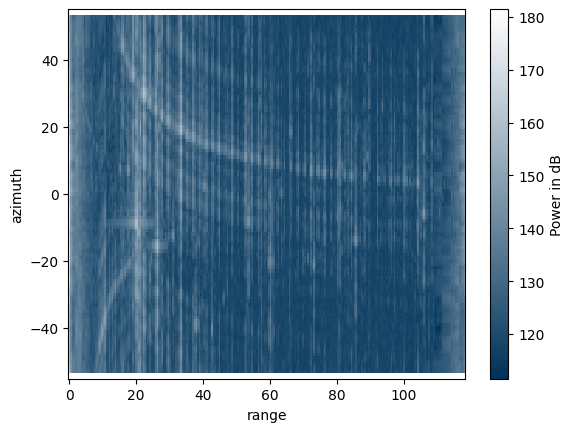

In [9]:
# Visualize the RA data
visu.visu_radar_tesseract(tesseract, dims='ra', raster=raster)

Unfortunatly, we are not used to work with data in polar coordinates, which is why this figure might be hard to interprete. Apart from that, the ground truth annotations are made in cartesian coordinates, which is why it might be benificial to visualize the data in cartesian coordinates. This can be easyly done by setting the cart argument to true.

/app/src/dprt/utils/visu.py:376: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p = ax.pcolormesh(x_mesh, y_mesh, rcs.T, cmap=cm, shading='nearest')


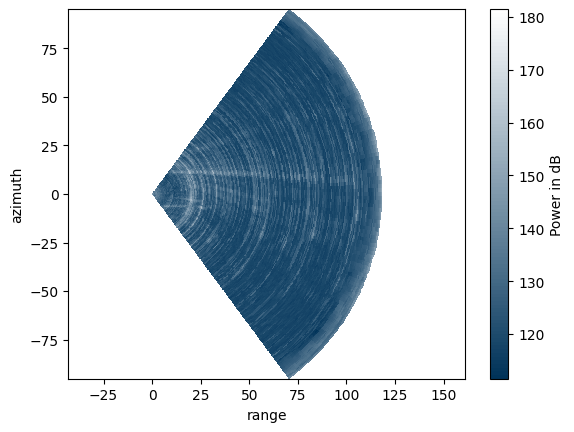

In [10]:
# Visualize the RA data in cartesian coordinates
visu.visu_radar_tesseract(tesseract, dims='ra', raster=raster, cart=True)

Finally, we can put everything together and visualize the radar data with the associated lidar data and object annotations. This gives us a very good understanding of the radar features associated with specific objects and structures. However, to do so we have to transform all data sources to the same coordinate frame. Therefore, we have to load the sensor calibration information, create a transformation matrix and transform the bounding boxes and lidar points.

/app/src/dprt/utils/visu.py:376: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  p = ax.pcolormesh(x_mesh, y_mesh, rcs.T, cmap=cm, shading='nearest')
/app/src/dprt/utils/visu.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


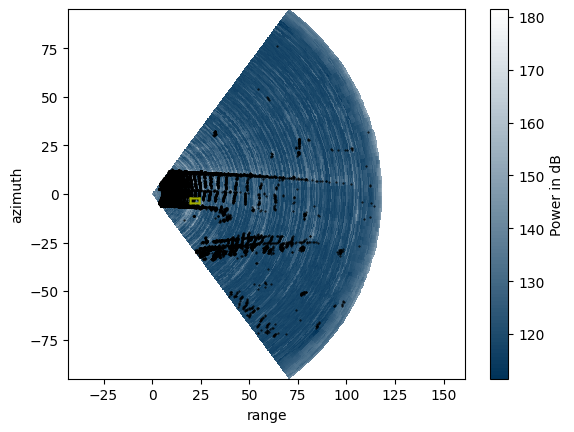

In [14]:
from dprt.utils.geometry import transform_boxes, transform_points

# Get calibration information
tm = preperator.get_translation(sample['calib_radar_lidar'])

# Transform boxes and points
boxes = transform_boxes(boxes, tm)
points = transform_points(point_cloud, tm)

# Visualize radar data
visu.visu_radar_tesseract(tesseract, dims='ra', raster=raster, boxes=boxes, points=points, roi=True, cart=True)